In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal, optimize
from scipy.special import factorial
import re

Funções Gerais

In [3]:
def load_spectrum(path):

    text = Path(path).read_text(encoding='utf-8', errors='ignore').splitlines()
    channels = []
    counts = []

    for line in text:
        match = re.match(r'\s*(\d+),\s*(\d+)', line)
        if match:
            channels.append(float(match.group(1)))
            counts.append(float(match.group(2)))
    
    return np.array(channels), np.array(counts)

def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def poisson(x, lamb):
    return (lamb ** x) * np.exp(-lamb) / factorial(x)

def compute_chi2(o, e, dof=None):
    mask = e > 0
    chi2 = np.sum(((o[mask] - e[mask]) ** 2) / e[mask])
    if dof is not None:
        return chi2 / dof
    return chi2

def compute_stat(canais, contagens, model=None):
    c = np.array(canais)
    N = np.array(contagens)

    N_t = np.sum(N)
    if N_t == 0:
        return 0, 0, None
    
    match model:
        case 'gaussian':
            popt, _ = optimize.curve_fit(gaussian, c, N, p0=[N_t, c[np.argmax(N)], np.std(c)])
            mu = popt[1]
            sigma = popt[2]/np.sqrt(N_t)
            y_fit = gaussian(c, *popt)
            dof = len(c) - 3
            chi2 = compute_chi2(N, y_fit, dof=dof)
            return mu, sigma, chi2
        case 'poisson':
            popt, _ = optimize.curve_fit(poisson, c, N, p0=[N_t/len(canais)])
            mu = popt[0]
            sigma = np.sqrt(mu/N_t)
            y_fit = poisson(c, *popt)
            dof = len(c) - 1
            chi2 = compute_chi2(N, y_fit, dof=dof)
            return mu, sigma, chi2
        case None:
            mu = np.sum(c * N) / N_t    
            sigma = np.sqrt(np.sum((c - mu) ** 2 * N)) / N_t

            return mu, sigma, float('nan')           

def linear(x, m, b):
    return m * x + b 

def calculate_centroid(canais, contagens):
    """Calculate centroid (weighted average) of a peak."""
    canais = np.array(canais)
    contagens = np.array(contagens)
    
    if np.sum(contagens) == 0:
        return 0, 0
        
    centroid = np.sum(canais * contagens) / np.sum(contagens)
    # Estimate sigma from peak width
    sigma = np.sqrt(np.sum((canais - centroid)**2 * contagens) / np.sum(contagens))
    
    return centroid, sigma


def kurie(energy, counts, Z, sigma_energy=None):
    if sigma_energy is None:
        sigma_ene = np.zeros_like(energy)
    else: sigma_ene = sigma_energy
    energy_total = energy + electron_mass_ene
    p_times_c = np.sqrt(energy**2 + 2*energy*electron_mass_ene)
    sigma_p_times_c = (energy + electron_mass_ene) / p_times_c * sigma_ene

    #fermi
    beta = p_times_c / energy_total
    sigma_beta = np.sqrt((sigma_p_times_c / energy_total)**2 + (p_times_c * sigma_ene / energy_total**2)**2)
    x = 2 * np.pi * alpha * Z / beta
    sigma_x = x * sigma_beta / beta
    F = x / (1 - np.exp(-x))
    sigma_F = (np.exp(x) * (np.exp(x) - x - 1))/(np.exp(x)-1)**2 * sigma_x

    #kurie

    K = np.sqrt(counts / (p_times_c * energy_total * F))
    sigma_K = 0.5 * K * np.sqrt((sigma_p_times_c / p_times_c)**2 + (sigma_ene / energy_total)**2 + (sigma_F / F)**2)

    return K, sigma_K

# Espectro do Tálio e Reta de Calibração

Espectro do tálio descoberto


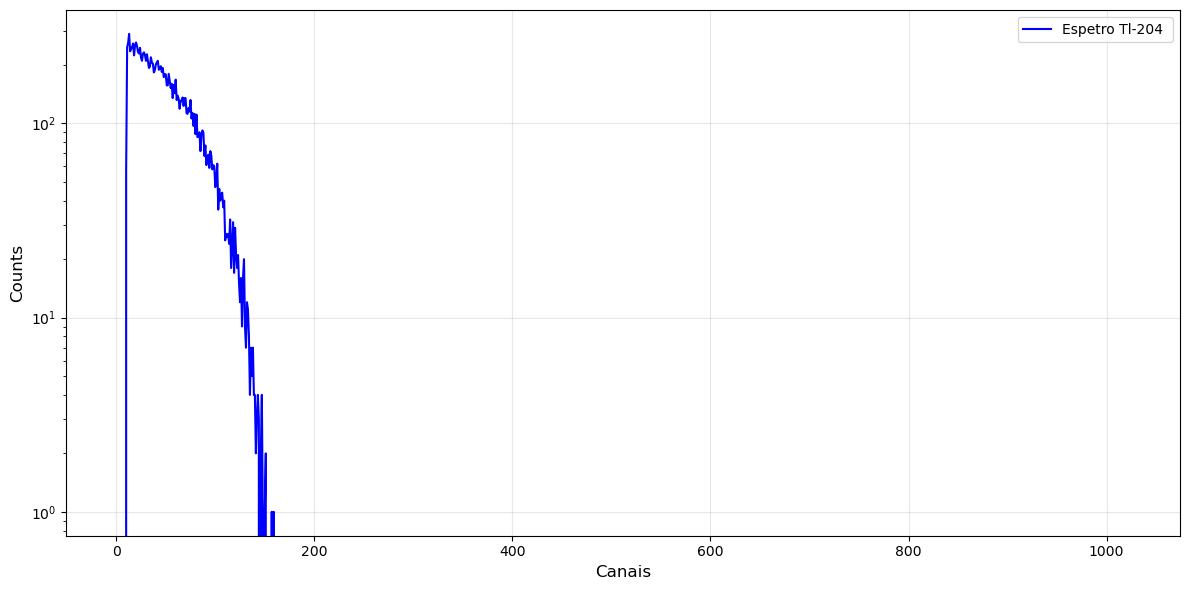

In [4]:
ch_tl , counts_tl = load_spectrum('tlsinv.ASC')



fig, ax = plt.subplots(figsize=(12, 6))
ax.plot( ch_tl, counts_tl, 'b-', linewidth=1.5, label='Espetro Tl-204 ')
ax.set_yscale('log')
ax.set_xlabel('Canais', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

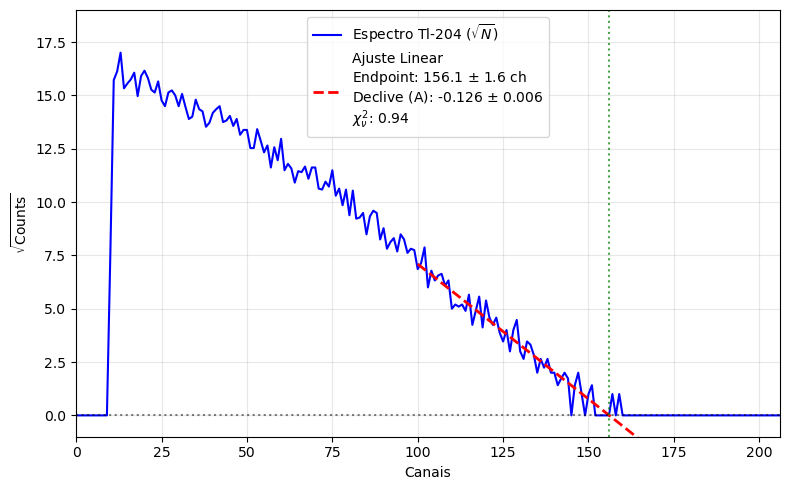

--- RESULTADOS DO AJUSTE ---
Canal do limite cinemático (x0): 156.07 ± 1.63 canais
Declive (A): -0.1265 ± 0.0058
Intercepto (B): 19.7427 ± 0.7093
Qui-quadrado reduzido: 0.94


In [5]:
# 1. Garanta que ambos são arrays do Numpy antes de usar a máscara
ch_tl_arr = np.array(ch_tl)
counts_tl_arr = np.array(counts_tl)

# 2. Aplica a máscara na região de queda linear
linear_region_mask = (ch_tl_arr > 100) & (ch_tl_arr < 145)

x_ajuste = ch_tl_arr[linear_region_mask]
y_ajuste = np.sqrt(counts_tl_arr[linear_region_mask])

# Erro dos pontos (Poisson propagado para a raiz quadrada = 0.5)
sigma_y = np.ones_like(y_ajuste) * 0.5

# 3. Faz o ajuste da reta extraindo a matriz de covariância (cov=True)
# w=1/sigma_y garante que o Python use os pesos estatísticos corretos
(A, B), cov = np.polyfit(x_ajuste, y_ajuste, 1, w=1/sigma_y, cov=True)

# Desvios padrão dos parâmetros A e B (raiz quadrada da diagonal da matriz de covariância)
sigma_A = np.sqrt(cov[0, 0])
sigma_B = np.sqrt(cov[1, 1])

# 4. Calcula o ponto de cruzamento no zero (Endpoint)
x0 = -B / A

# Propagação de erro para encontrar o desvio padrão de x0 (sigma_x0)
# Usando a fórmula de quadratura com o termo de covariância cruzada cov[0,1]
sigma_x0 = x0 * np.sqrt((sigma_B / B)**2 + (sigma_A / A)**2 - 2 * cov[0, 1] / (A * B))

# Qui-Quadrado Reduzido
y_predito = A * x_ajuste + B
chi2_reduzido = np.sum(((y_ajuste - y_predito) / sigma_y) ** 2) / (len(x_ajuste) - 2)

# 5. Cria o eixo X estendido para a reta tocar o chão
x_reta = np.linspace(100, x0 + 10, 100)
y_reta = A * x_reta + B

# ===========================================================================
# BLOCO DE PLOTAGEM
# ===========================================================================
fig, ax = plt.subplots(figsize=(8, 5))

# Dados reais em raiz quadrada
ax.plot(ch_tl_arr, np.sqrt(counts_tl_arr), 'b-', label=r'Espectro Tl-204 ($\sqrt{N}$)')

# Reta de ajuste com os desvios padrão inclusos na legenda
label_ajuste = (
    fr'Ajuste Linear' + '\n' +
    fr'Endpoint: {x0:.1f} $\pm$ {sigma_x0:.1f} ch' + '\n' +
    fr'Declive (A): {A:.3f} $\pm$ {sigma_A:.3f}' + '\n' +
    fr'$\chi^2_\nu$: {chi2_reduzido:.2f}'
)
ax.plot(x_reta, y_reta, 'r--', linewidth=2, label=label_ajuste)

# Linhas de guia para o zero e para o ponto encontrado
ax.axhline(0, color='black', linestyle=':', alpha=0.5)
ax.axvline(x0, color='green', linestyle=':', alpha=0.7)

# Configurações visuais do gráfico
ax.set_xlim(0, x0 + 50)
ax.set_ylim(-1, np.sqrt(max(counts_tl_arr)) + 2)
ax.set_xlabel('Canais')
ax.set_ylabel(r'$\sqrt{\text{Counts}}$')

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# Print dos resultados detalhados no terminal
print(f"--- RESULTADOS DO AJUSTE ---")
print(f"Canal do limite cinemático (x0): {x0:.2f} ± {sigma_x0:.2f} canais")
print(f"Declive (A): {A:.4f} ± {sigma_A:.4f}")
print(f"Intercepto (B): {B:.4f} ± {sigma_B:.4f}")
print(f"Qui-quadrado reduzido: {chi2_reduzido:.2f}")

--- 1. Estatística dos Picos (Pulsers) ---
Pulser02.asc -> Centroide: 41.38 | σ (Largura): 0.9566 | Erro Padrão: 0.023715
Pulser04.asc -> Centroide: 86.95 | σ (Largura): 2.5865 | Erro Padrão: 0.064065
Pulser06.asc -> Centroide: 129.62 | σ (Largura): 0.7681 | Erro Padrão: 0.019043
Pulser08.asc -> Centroide: 172.41 | σ (Largura): 2.6267 | Erro Padrão: 0.065101
Pulser10.asc -> Centroide: 217.78 | σ (Largura): 4.9831 | Erro Padrão: 0.123463
Pulser12.asc -> Centroide: 263.35 | σ (Largura): 5.6824 | Erro Padrão: 0.140789


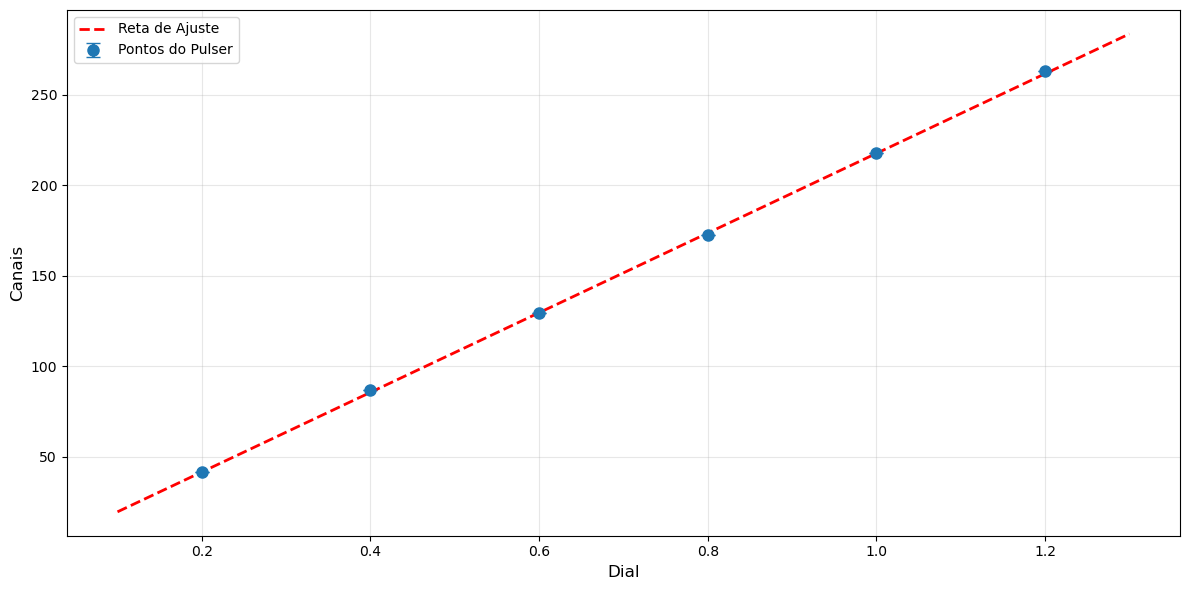

m_p = 220.275293 ± 1.002414 canais/dial
b_p = -2.57 ± 0.52 canais
χ²_red = 0.0105


In [6]:
dados_arquivos = {
    'Pulser02.asc': (0, 1024), 'Pulser04.asc': (0, 1024), 'Pulser06.asc': (0, 1024),
    'Pulser08.asc': (0, 1024), 'Pulser10.asc': (0, 1024), 'Pulser12.asc': (0, 1024)
}

centroides_p = []
erros_centroide_p = []

print("--- 1. Estatística dos Picos (Pulsers) ---")
for arquivo, (c_min, c_max) in dados_arquivos.items():
    try:
        canais, contagens = load_spectrum(arquivo)
        mascara = (canais >= c_min) & (canais <= c_max)
        
        c_roi, n_roi = canais[mascara], contagens[mascara]
        centroide_pulser, sigma_pulser = calculate_centroid(c_roi, n_roi)
        
        # Erro padrão da posição do centroide
        erro_c = sigma_pulser / np.sqrt(np.sum(n_roi))
        
        centroides_p.append(centroide_pulser)
        erros_centroide_p.append(erro_c)
        
        print(f"{arquivo} -> Centroide: {centroide_pulser:.2f} | \u03c3 (Largura): {sigma_pulser:.4f} | Erro Padrão: {erro_c:.6f}")
    except FileNotFoundError:
        print(f"Ficheiro {arquivo} não encontrado.")
pulser_C = np.array(centroides_p)
pulser_C_sigma = np.array(erros_centroide_p)
pulser_D = np.array([0.2, 0.4, 0.6, 0.8, 1.0, 1.2])

popt, pcov = optimize.curve_fit(linear, pulser_D, pulser_C, sigma = pulser_C_sigma)
perr = np.sqrt(np.diag(pcov))

pulser_C_fit = linear(pulser_D, *popt)

chi2 = compute_chi2(pulser_C, pulser_C_fit, dof=len(pulser_C) - 2)

fig, ax = plt.subplots(figsize=(12, 6))
ax.errorbar(pulser_D, pulser_C, yerr=pulser_C_sigma, fmt='o', markersize=8, capsize=5, elinewidth=2, label='Pontos do Pulser')
D_plot = np.linspace(pulser_D.min() - 0.1, pulser_D.max() + 0.1, 100)
ax.plot(D_plot, linear(D_plot, *popt), 'r--', linewidth=2, label=f'Reta de Ajuste')
ax.set_xlabel('Dial', fontsize=12)
ax.set_ylabel('Canais', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"m_p = {popt[0]:.6f} ± {perr[0]:.6f} canais/dial")
print(f"b_p = {popt[1]:.2f} ± {perr[1]:.2f} canais")
print(f"χ²_red = {chi2:.4f}")

o Valor Teiorico é 0.764Mev

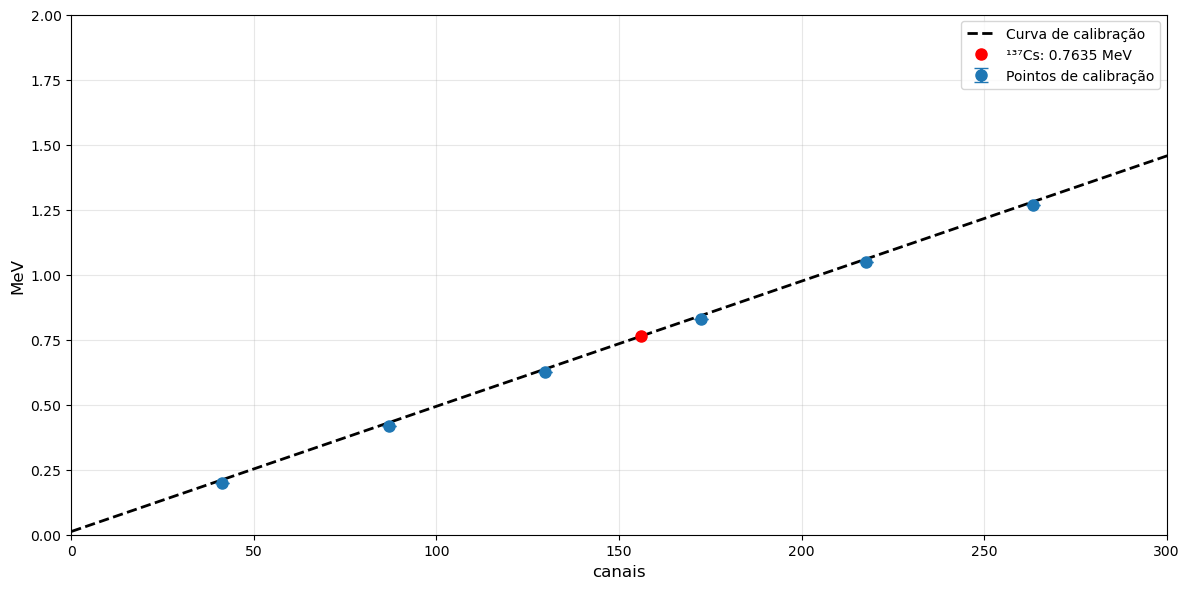

--- Parâmetros da Reta de Calibração ---
m (declive): 4.812856e-03 ± 6.046335e-05 MeV/canal
b (intercepto): 1.235759e-02 ± 2.517662e-03 MeV


In [7]:
tl_teo = 0.7635 
tl_cent = 156.07
tl_sigma = 1.63 


cs_conv_dial = (tl_cent - popt[1]) / popt[0]
cs_conv_dial_sigma = np.sqrt((tl_sigma / popt[0]) ** 2 + ((tl_cent - popt[1]) * perr[0] / popt[0] ** 2) ** 2 + (perr[1] / popt[0]) ** 2)

kappa = tl_teo / cs_conv_dial
kappa_sigma = np.abs(tl_teo / cs_conv_dial ** 2) * cs_conv_dial_sigma

pulser_energies = kappa * pulser_D
#A incerteza dos dials é 0.01, menor divisão da escala
pulser_energies_sigma = np.sqrt((kappa_sigma * pulser_D) ** 2 + (kappa * 0.01) ** 2)

m = kappa/ popt[0]
m_sigma = np.sqrt((perr[0] * kappa/ popt[0]**2) ** 2 + (kappa_sigma/popt[0]) ** 2)
b = -popt[1] * kappa/popt[0]
b_sigma = np.sqrt((perr[1] * kappa / popt[0]) ** 2 + (popt[1] * kappa_sigma / popt[0]) ** 2 + (popt[1] * kappa * perr[0] / popt[0] ** 2) ** 2)

channels_plot = np.linspace(0, 1200, 1000)
energy_plot = m * channels_plot + b

pulser_energies_calib = m * pulser_C
print

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(channels_plot, energy_plot, 'k--', linewidth=2, label='Curva de calibração')
ax.set_xlim(0, 300)
ax.set_ylim(0, 2)

ax.errorbar(pulser_C, pulser_energies_calib, yerr=pulser_C_sigma * m, fmt='o', markersize=8, capsize=5, elinewidth=2, label='Pointos de calibração')

ax.plot(tl_cent, tl_teo, 'ro', markersize=8, label=f'¹³⁷Cs: {tl_teo:.4f} MeV')

ax.set_xlabel('canais', fontsize=12)
ax.set_ylabel('MeV', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# --- PRINT DOS PARÂMETROS DA RETA ---
print("--- Parâmetros da Reta de Calibração ---")
print(f"m (declive): {m:.6e} ± {m_sigma:.6e} MeV/canal")
print(f"b (intercepto): {b:.6e} ± {b_sigma:.6e} MeV")

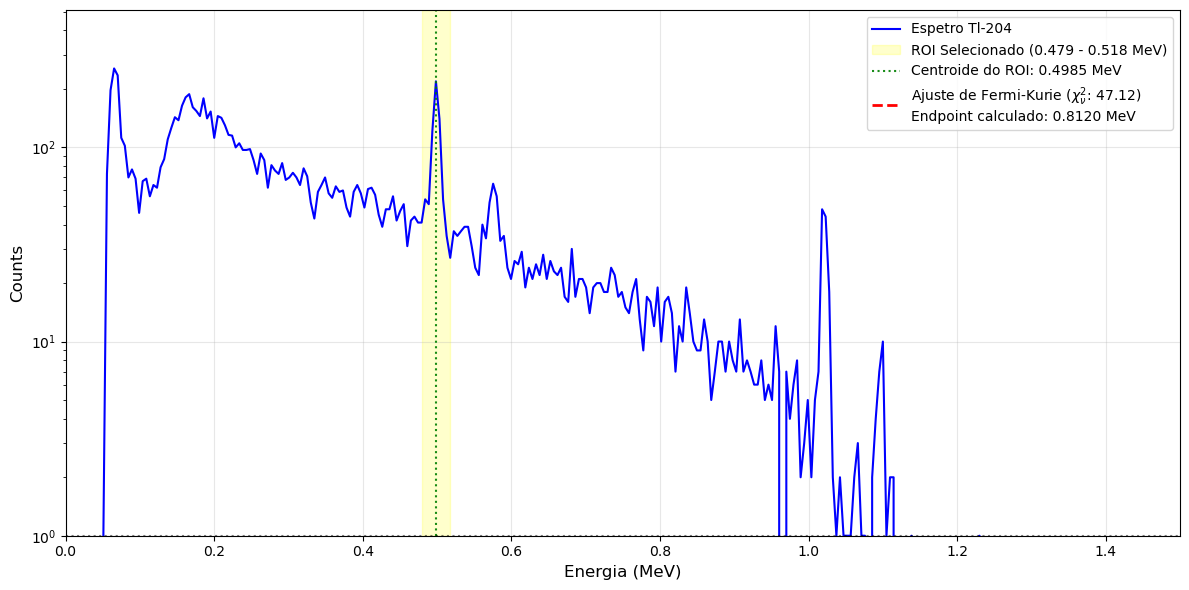

--- RESULTADOS DA REGIÃO SELECIONADA ---
Intervalo de canais: 97 a 105
Centroide do ROI: 0.4985 MeV
Endpoint calculado: 0.8120 MeV
Qui-quadrado reduzido: 47.12


In [8]:
# ===========================================================================
# 1. ESCOLHA O INTERVALO (ROI) EM CANAIS AQUI
# ===========================================================================
canal_roi_inf = 97
canal_roi_sup = 105

# ===========================================================================
# 2. CARREGAMENTO E CONVERSÃO DOS DADOS
# ===========================================================================
ch_tl, counts_tl = load_spectrum('bi600.ASC')

# Convertendo canais e contagens para arrays do Numpy para aplicar as máscaras
ch_tl_arr = np.array(ch_tl)
counts_tl_arr = np.array(counts_tl)

# Escala de energia calibrada (MeV)
energy_tl = m * ch_tl_arr + b 

# Convertendo os limites escolhidos do ROI para Energia (MeV)
roi_energia_inf = m * canal_roi_inf + b
roi_energia_sup = m * canal_roi_sup + b

# CÁLCULO DO CENTROIDE DO ROI (Ponto central em energia)
centroide_energia = (roi_energia_inf + roi_energia_sup) / 2

# ===========================================================================
# 3. AJUSTE LINEAR DA RETA NA REGIÃO DO ROI (Usando a raiz quadrada)
# ===========================================================================
mask_ajuste = (ch_tl_arr >= canal_roi_inf) & (ch_tl_arr <= canal_roi_sup) & (counts_tl_arr > 0)
x_ajuste = ch_tl_arr[mask_ajuste]
y_ajuste = np.sqrt(counts_tl_arr[mask_ajuste])

# Ajuste da reta em canais brutos: y = A_ch * x + B_ch
A_ch, B_ch = np.polyfit(x_ajuste, y_ajuste, 1)

# Canal do Endpoint bruto e cálculo do Chi2 Reduzido
x0_ch = -B_ch / A_ch
chi2_reduzido = np.sum(((y_ajuste - (A_ch * x_ajuste + B_ch)) / 0.5) ** 2) / (len(x_ajuste) - 2)

# Convertendo o Endpoint para Energia (MeV)
E0_mev = m * x0_ch + b

# Transforma o declive da reta para a escala de Energia (MeV)
A_mev = A_ch / m

# Gera os pontos da reta para plotar no gráfico de energia
eixo_e_reta = np.linspace(roi_energia_inf, E0_mev + 0.05, 100)
reta_plot_counts = (A_mev * (eixo_e_reta - b)/m + B_ch) ** 2  # Elevado ao quadrado para bater com o eixo Y linear de Counts

# ===========================================================================
# 4. BLOCO DE PLOTAGEM
# ===========================================================================
fig, ax = plt.subplots(figsize=(12, 6))

# Dados do espectro do Tálio
ax.plot(energy_tl, counts_tl, 'b-', linewidth=1.5, label='Espetro Tl-204')

# Adiciona o ROI (Faixa amarela sombreada) no intervalo escolhido
ax.axvspan(roi_energia_inf, roi_energia_sup, color='yellow', alpha=0.2, 
           label=f'ROI Selecionado ({roi_energia_inf:.3f} - {roi_energia_sup:.3f} MeV)')

# --- ALTERADO: Linha vertical tracejada verde agora fica exatamente no centroide do ROI ---
ax.axvline(centroide_energia, color='green', linestyle=':', alpha=0.9, 
           label=f'Centroide do ROI: {centroide_energia:.4f} MeV')

# Adiciona a reta de ajuste projetada até o chão (convertida de volta para Counts)
ax.plot(eixo_e_reta, reta_plot_counts, 'r--', linewidth=2, 
        label=fr'Ajuste de Fermi-Kurie ($\chi^2_\nu$: {chi2_reduzido:.2f})' + '\n' + fr'Endpoint calculado: {E0_mev:.4f} MeV')

# Linhas de guia para o nível base Y = 1
ax.axhline(1, color='black', linestyle=':', alpha=0.5)

# Configurações dos eixos (mantendo o seu padrão em log)
ax.set_yscale('log')
ax.set_xlim(0, 1.5)
ax.set_ylim(1, max(counts_tl_arr) * 2)
ax.set_xlabel('Energia (MeV)', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"--- RESULTADOS DA REGIÃO SELECIONADA ---")
print(f"Intervalo de canais: {canal_roi_inf} a {canal_roi_sup}")
print(f"Centroide do ROI: {centroide_energia:.4f} MeV")
print(f"Endpoint calculado: {E0_mev:.4f} MeV")
print(f"Qui-quadrado reduzido: {chi2_reduzido:.2f}")

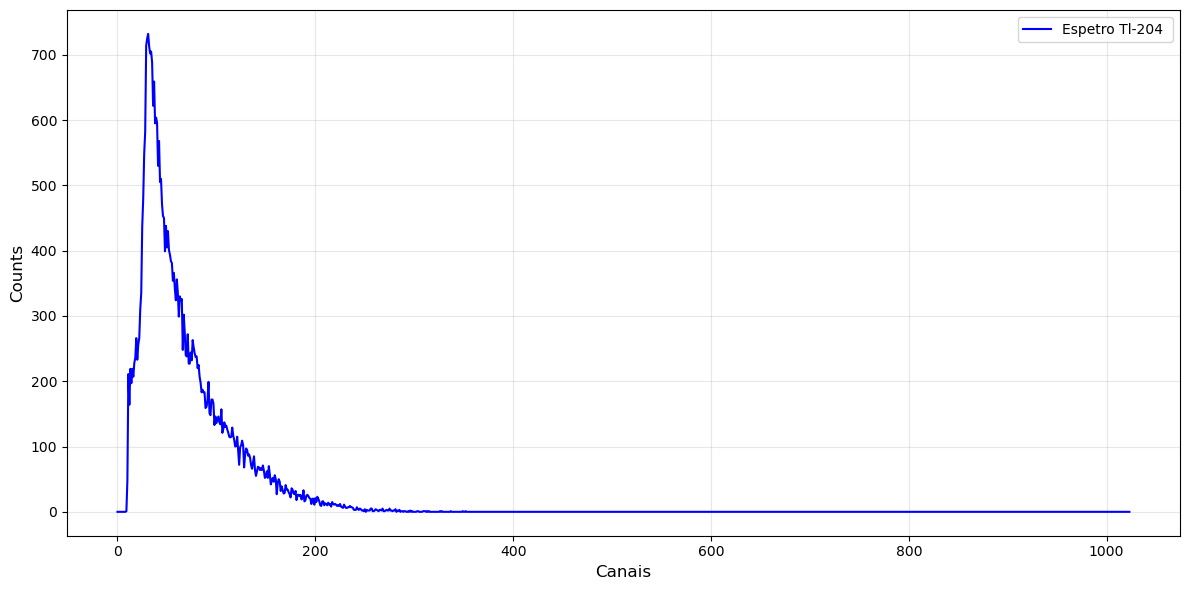

In [ ]:
ch_tl , counts_tl = load_spectrum('str600.ASC')



fig, ax = plt.subplots(figsize=(12, 6))
ax.plot( ch_tl, counts_tl, 'b-', linewidth=1.5, label='Espetr')
ax.set_xlabel('Canais', fontsize=12)
ax.set_ylabel('Counts', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()